In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

#### Gameplay functions (Hide this section)

In [2]:
def take_turn(scores, strategies, me, opponent, is_last_chance_round):
    turn_report = []
    roll_count = 0
    turn_score = 0
    superskunk = False

    while True:
        state = {"bot_score_before_turn": int(scores[me]),
                 "opponent_score_before_turn": int(scores[opponent]),
                 "roll_count": roll_count,
                 "turn_score": turn_score,
                 "is_last_chance_round": is_last_chance_round}

        roll_decision = strategies[me](state)
        if not roll_decision:
            turn_report.append(
                {**state, "roll_decision": False, "die_one": None, "die_two": None})
            break

        die_one, die_two = random.randint(1, 6), random.randint(1, 6)
        roll_count += 1

        if die_one == 1 and die_two == 1:
            superskunk = True
            turn_score = 0
            turn_report.append(
                {**state, "roll_decision": True, "die_one": die_one, "die_two": die_two})
            break
        elif die_one == 1 or die_two == 1:
            turn_score = 0
            turn_report.append(
                {**state, "roll_decision": True, "die_one": die_one, "die_two": die_two})
            break
        else:
            turn_score += (die_one + die_two)
            turn_report.append(
                {**state, "roll_decision": True, "die_one": die_one, "die_two": die_two})

    return turn_score, turn_report, superskunk

In [3]:
def simulate_game(bot_1, bot_2, game_id=1):
    scores = {bot_1["name"]: 0, bot_2["name"]: 0}
    strategies = {bot_1["name"]: bot_1["strategy"],
                  bot_2["name"]: bot_2["strategy"]}
    players = [bot_1["name"], bot_2["name"]]
    is_last_chance_round = False
    game_report = []
    target = 100
    turn_id = 1

    # print(scoreboard)
    # Loop for one round that ends when target is reached (with last chance round for p2)
    while True:
        if turn_id == 100000:
            print("WARNING - infinite loop")
            break  # you're missing this
        # Player 1
        me, opponent = players[0], players[1]
        turn_score, turn_report, superskunk = take_turn(
            scores, strategies, me, opponent, is_last_chance_round)
        scores[me] = 0 if superskunk else scores[me] + turn_score
        for row in turn_report:
            row["player"] = me
            row["turn_id"] = turn_id
        game_report.extend(turn_report)
        if scores[me] >= target:
            is_last_chance_round = True
        turn_id += 1

        # Player 2
        me, opponent = players[1], players[0]
        turn_score, turn_report, superskunk = take_turn(
            scores, strategies, me, opponent, is_last_chance_round)
        scores[me] = 0 if superskunk else scores[me] + turn_score
        for row in turn_report:
            row["player"] = me
            row["turn_id"] = turn_id
        game_report.extend(turn_report)
        turn_id += 1

        if is_last_chance_round or scores[players[1]] >= target:
            if scores[players[0]] > scores[players[1]]:
                winner = players[0]
                bot_1["wins"] += 1
                bot_2["losses"] += 1
            elif scores[players[1]] > scores[players[0]]:
                winner = players[1]
                bot_2["wins"] += 1
                bot_1["losses"] += 1
            else:
                winner = "tie"

            for row in game_report:
                row["winner"] = winner
                row["game_id"] = game_id
            break
    return game_report

In [4]:
def simulate_games(bot_1, bot_2, games_to_simulate, matchup_id):
    matchup_report = []
    bot_1_game_wins = 0
    bot_2_game_wins = 0
    for game in range(games_to_simulate):
        game_report = simulate_game(bot_1, bot_2, game_id=game+1)
        matchup_report.extend(game_report)
        # last row of game_report has the winner
        winner = game_report[-1]["winner"]
        if winner == bot_1["name"]:
            bot_1_game_wins += 1
        elif winner == bot_2["name"]:
            bot_2_game_wins += 1
    for row in matchup_report:
        row["matchup_id"] = matchup_id
    # increment match_wins on the winner
    if bot_1_game_wins > bot_2_game_wins and "match_wins" in bot_1:
        bot_1["match_wins"] += 1
    elif bot_2_game_wins > bot_1_game_wins and "match_wins" in bot_2:
        bot_2["match_wins"] += 1
    return matchup_report

# EV Maximizing Bot:

In [21]:
# Example state
test_state = {"bot_score_before_turn": 69,
        "opponent_score_before_turn": 52,
        "roll_count": 12,
        "turn_score": 5,
        "is_last_chance_round": False}

p_superskunk = 1/36
p_skunk = 10/36
p_safe = 25/36

# To find the average EV of one roll I took the sum of all dice rolls without 1s and divided by the probability of getting a safe roll 
dice = np.arange(2, 7)
dice_df = pd.DataFrame(
    np.add.outer(dice, dice),
    index=dice,
    columns=dice
)
ev_safe_roll = dice_df.to_numpy().sum() / 25

# Possible outcomes
outcome_stop = test_state["bot_score_before_turn"] + test_state["turn_score"]
outcome_safe = test_state["bot_score_before_turn"] + test_state["turn_score"] + ev_safe_roll
outcome_skunk = test_state["bot_score_before_turn"] + 0
outcome_superskunk = 0

# Calculating the expected value of one more roll
ev_one_more_roll = (p_safe * outcome_safe) + (p_skunk * outcome_skunk) + (p_superskunk * outcome_superskunk)
print(f'The expected total points of the bot after rolling again is {round((ev_one_more_roll),2)} points')

The expected total points of the bot after rolling again is 76.11 points


In [6]:
def paramaterized_heuristic_bot(state):
    p_superskunk = 1/36
    p_skunk = 10/36
    p_safe = 25/36
    ev_safe_roll = 8
    outcome_stop = state["bot_score_before_turn"] + state["turn_score"]
    outcome_safe = state["bot_score_before_turn"] + \
        state["turn_score"] + ev_safe_roll
    outcome_skunk = state["bot_score_before_turn"] + 0
    outcome_superskunk = 0
    ev_one_more_roll = (p_safe * outcome_safe) + (p_skunk *
                                                  outcome_skunk) + (p_superskunk * outcome_superskunk)

    if outcome_stop < ev_one_more_roll:
        return True
    else:
        return False
    
test_bot_output = paramaterized_heuristic_bot(test_state)
print(test_bot_output)

True


In [7]:
random_bot = {
    "generation": "random",
    "id": "random",
    "name": f"random_bot",
    "strategy": lambda state: random.choice([True, False]),
    "wins": 0,
    "losses": 0,
    "match_wins": 0}


In [8]:
ev_bot = {
    "generation": "ev_bot",
    "id": "ev_bot",
    "name": "ev_bot",
    "strategy": lambda state: paramaterized_heuristic_bot(state),
    "wins": 0,
    "losses": 0,
    "match_wins": 0}

In [ ]:
# Simulate 10,000 games and generate a post game summary
random_vs_ev = simulate_games(ev_bot, random_bot, 10000, 1)
random_vs_ev_df = pd.DataFrame(random_vs_ev)
wins = random_vs_ev_df.groupby("game_id")["winner"].first().value_counts()
print(wins)

winner
ev_bot        8955
random_bot    1040
tie              5
Name: count, dtype: int64


# Probability Table Lookup Bot

Note - the code for filling in and creating the probability tables is located:
 - [Here](/recursion_algo.py) for my original version using recursivity
 - [Here](/recursion_algo_estimates.py) for the working version using increasingly accurate estimates

In [9]:
# Bring in probability table but switch to a dict for fast lookups
prob_df = pd.read_csv('skunk_optimal.csv')
lookup = prob_df.set_index(['player', 'my_score', 'opp_score', 'turn_score']).to_dict('index')

In [10]:
def prob_table_strat(state):
    # game function does not return a player variable but I know which I am based on placement, have to change manually
    player = 'p1'
    my_score = state["bot_score_before_turn"]
    opp_score = state["opponent_score_before_turn"]
    turn_score = state["turn_score"]

    # bank if winning:
    if my_score + turn_score >= 100:
        return False
    
    row = lookup[('p1', my_score, opp_score, turn_score)]
    p_win_if_roll = row['p_win_if_roll']
    p_win_if_bank = row['p_win_if_bank']
    if p_win_if_roll >p_win_if_bank:
        return True
    else:
        return False

prob_table_bot = {
    "generation": "prob_table_bot",
    "id": "prob_table_bot",
    "name": "prob_table_bot",
    "strategy": prob_table_strat,
    "wins": 0,
    "losses": 0,
    "match_wins": 0}

In [20]:
# Simulate 10,000 games and generate a post game summary
ev_vs_prob_table = simulate_games(prob_table_bot, ev_bot, 10000, 1)
ev_vs_prob_table_df = pd.DataFrame(ev_vs_prob_table)
wins = ev_vs_prob_table_df.groupby("game_id")["winner"].first().value_counts()
print(wins)

winner
prob_table_bot    5460
ev_bot            4508
tie                 32
Name: count, dtype: int64


In [18]:
# Simulate 10,000 games and generate a post game summary
random_vs_prob_table = simulate_games(prob_table_bot, random_bot, 10000, 1)
random_vs_prob_table_df = pd.DataFrame(random_vs_prob_table)
wins = random_vs_prob_table_df.groupby("game_id")["winner"].first().value_counts()
print(wins)

winner
prob_table_bot    8938
random_bot        1058
tie                  4
Name: count, dtype: int64


# Probability Table Bot vs EV Bot Charts

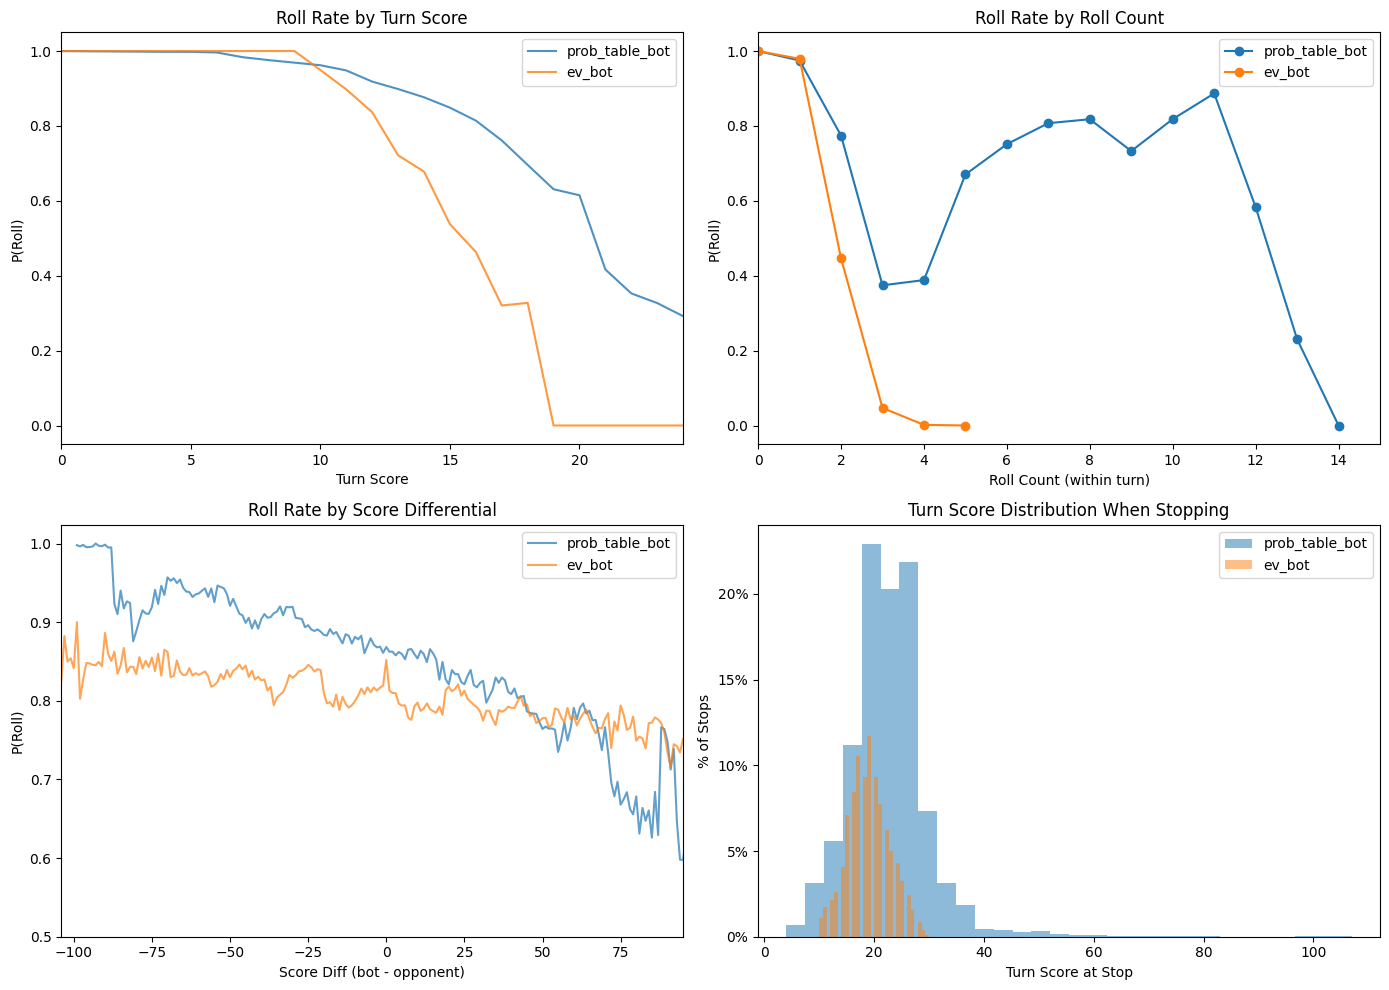

In [ ]:
# Split by bot
prob_df = ev_vs_prob_table_df[ev_vs_prob_table_df["player"] == "prob_table_bot"]
ev_df = ev_vs_prob_table_df[ev_vs_prob_table_df["player"] == "ev_bot"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

max_turn = int(ev_vs_prob_table_df["turn_score"].quantile(0.95))

prob_roll_by_ts = prob_df.groupby("turn_score")["roll_decision"].mean()
ev_roll_by_ts = ev_df.groupby("turn_score")["roll_decision"].mean()

# 1
ax = axes[0, 0]
ax.plot(prob_roll_by_ts.index, prob_roll_by_ts.values, label="prob_table_bot", alpha=0.8)
ax.plot(ev_roll_by_ts.index, ev_roll_by_ts.values, label="ev_bot", alpha=0.8)
ax.set_xlabel("Turn Score")
ax.set_ylabel("P(Roll)")
ax.set_title("Roll Rate by Turn Score")
ax.set_xlim(0, max_turn)
ax.legend()

# 2
prob_roll_by_rc = prob_df.groupby("roll_count")["roll_decision"].mean()
ev_roll_by_rc = ev_df.groupby("roll_count")["roll_decision"].mean()

ax = axes[0, 1]
ax.plot(prob_roll_by_rc.index, prob_roll_by_rc.values, marker='o', label="prob_table_bot")
ax.plot(ev_roll_by_rc.index, ev_roll_by_rc.values, marker='o', label="ev_bot")
ax.set_xlabel("Roll Count (within turn)")
ax.set_ylabel("P(Roll)")
ax.set_title("Roll Rate by Roll Count")
ax.set_xlim(0, 15)
ax.legend()

# 3
prob_df = prob_df.copy()
ev_df = ev_df.copy()
prob_df["score_diff"] = prob_df["bot_score_before_turn"] - prob_df["opponent_score_before_turn"]
ev_df["score_diff"] = ev_df["bot_score_before_turn"] - ev_df["opponent_score_before_turn"]

prob_roll_by_diff = prob_df.groupby("score_diff")["roll_decision"].mean()
ev_roll_by_diff = ev_df.groupby("score_diff")["roll_decision"].mean()

ax = axes[1, 0]
lo = int(ev_vs_prob_table_df["bot_score_before_turn"].quantile(0.01) - ev_vs_prob_table_df["opponent_score_before_turn"].quantile(0.99))
hi = int(ev_vs_prob_table_df["bot_score_before_turn"].quantile(0.99) - ev_vs_prob_table_df["opponent_score_before_turn"].quantile(0.01))
ax.plot(prob_roll_by_diff.index, prob_roll_by_diff.values, alpha=0.7, label="prob_table_bot")
ax.plot(ev_roll_by_diff.index, ev_roll_by_diff.values, alpha=0.7, label="ev_bot")
ax.set_xlabel("Score Diff (bot - opponent)")
ax.set_ylabel("P(Roll)")
ax.set_title("Roll Rate by Score Differential")
ax.set_xlim(lo, hi)
ax.legend()

# 4
prob_stops = prob_df[prob_df["roll_decision"] == False]["turn_score"]
ev_stops = ev_df[ev_df["roll_decision"] == False]["turn_score"]

ax = axes[1, 1]
ax.hist(prob_stops, bins=30, alpha=0.5, label="prob_table_bot", weights=np.ones(len(prob_stops)) / len(prob_stops))
ax.hist(ev_stops, bins=30, alpha=0.5, label="ev_bot", weights=np.ones(len(ev_stops)) / len(ev_stops))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel("Turn Score at Stop")
ax.set_ylabel("% of Stops")
ax.set_title("Turn Score Distribution When Stopping")
ax.legend()

plt.tight_layout()
plt.show()